# BigAlpha 5m 缩小六头 AttnLOB
将本 Notebook 和所有 `server5m_*.py`、`server_5m_small.py` 逐个上传到同一级目录。先训练保存固定最佳权重；平台调用 main 时只读注入的 bar5m 测试表。
不需要上传任何文件夹，也没有压缩包或动态解压。所有 Python 文件必须与 Notebook 同级。


In [1]:
from server_5m_small import (
    DEFAULT_CONFIG,
    build_data_cache,
    train,
    main as _model_main,
)

cfg = dict(DEFAULT_CONFIG)
cfg.update({
    'optimizer': 'adamw',
    'run_name': 'server_5m_attn_small_adamw',
    'force_query': False,
    'force_cache': False,
})
cfg


{'query_start': '2022-01-01 00:00:00',
 'query_end': '2024-12-31 23:59:59',
 'normalized_parquet': 'cache/server_5m_normalized_2022_2024.parquet',
 'cache_dir': 'cache/server_5m_small_cache',
 'force_query': False,
 'force_cache': False,
 'run_name': 'server_5m_attn_small_adamw',
 'output_root': 'training_results/server_5m_small',
 'optimizer': 'adamw',
 'lr': 0.001,
 'weight_decay': 0.0001,
 'batch_size': 1024,
 'epochs': 50,
 'feature_dim': 32,
 'head_dim': 16,
 'dropout': 0.15,
 'regression_weights': [0.25, 0.15, 0.1],
 'classification_weights': [1.0, 0.5, 0.25],
 'ordinal_sigma': 0.7,
 'selection_score': 'cls_blend_532',
 'early_stop_metric': 'loss',
 'early_stop_patience': 10,
 'grad_clip': 1.0,
 'num_workers': 0,
 'amp': True,
 'seed': 42}

In [2]:
def train_and_save(config=None):
    """读取数据 + 构建缓存 + 训练，并将最佳模型与配置保存到本 Notebook 同级目录。"""
    run_cfg = {**cfg, **(config or {})}
    normalized_file, cache_dir = build_data_cache(run_cfg)
    summary = train(run_cfg)
    summary['normalized_file'] = str(normalized_file)
    summary['cache_dir'] = str(cache_dir)
    return summary


In [3]:
def predict(datasources, start_date, end_date):
    """使用同级目录中已保存的最佳模型进行推理。"""
    return _model_main(datasources, start_date, end_date)


In [4]:
def main(datasources, start_date, end_date):
    return predict(datasources, start_date, end_date)


In [5]:
# 执行训练（按需取消注释）：
# summary = train_and_save()
# summary


[2026-07-28 11:38:45][INFO] ============================================================
[2026-07-28 11:38:45][INFO] [main] start datasources=['bar5m'] range=[2019-01-01 00:00:00, 2024-12-31 23:59:59]
[2026-07-28 11:38:45][INFO] [mem] main start rss=584.5MB
[2026-07-28 11:38:45][INFO] [main] table=bigalpha_2026_stock_bar5m
[2026-07-28 11:38:45][INFO] [main] fetching instrument pool
[2026-07-28 11:38:45][INFO] [main] pool rows=1456000 unique_instruments=2075 elapsed=0.2s
[2026-07-28 11:38:45][INFO] [mem] after pool rss=929.5MB
[2026-07-28 11:38:45][INFO] [main] year_chunks=6 total_days=2191 use_chunked=True
[2026-07-28 11:38:45][INFO] [main] chunk 1/6 2019-01-01 00:00:00 ~ 2019-12-31 23:59:59
[2026-07-28 11:38:45][INFO] [main] chunk 2/6 2020-01-01 00:00:00 ~ 2020-12-31 23:59:59
[2026-07-28 11:38:45][INFO] [main] chunk 3/6 2021-01-01 00:00:00 ~ 2021-12-31 23:59:59
[2026-07-28 11:38:45][INFO] [main] chunk 4/6 2022-01-01 00:00:00 ~ 2022-12-31 23:59:59
[2026-07-28 11:38:45][INFO] [main] chu

        date instrument     score
0 2019-01-02  000011.SZ -0.398400
1 2019-01-02  000016.SZ  0.100762
2 2019-01-02  000018.SZ  1.113952
3 2019-01-02  000030.SZ  0.922350
4 2019-01-02  000034.SZ -1.216553 1452626 1456
[2026-07-28 11:43:55] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-28 11:43:56] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-28 11:43:56] [info     ] 因子列名不为 factor, 自动重命名
[2026-07-28 11:43:56] [info     ] 未提供因子池，只进行单因子分析
[2026-07-28 11:43:56] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-28 11:43:57] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2019-01-02 至 2024-12-31
[2026-07-28 11:43:57] [info     ] ========== 数据检查 ==========
[2026-07-28 11:43:57] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
[2026-07-28 11:43:57] [info     ] 通过：唯一性检查
[2026-07-28 11:43:57] [info     ] 通过：factor 有限值检查（禁止 inf/-inf）
[2026-07-28 11:43:57] [info     ] 通过：缺日检查（无整日全缺的交易日）
[2026-07-28 11:43:57] [info 

时段,IC
2020-02-03~2020-03-31,0.0184
2024-01-15~2024-02-08,0.0177
2024-09-24~2024-10-08,0.0223

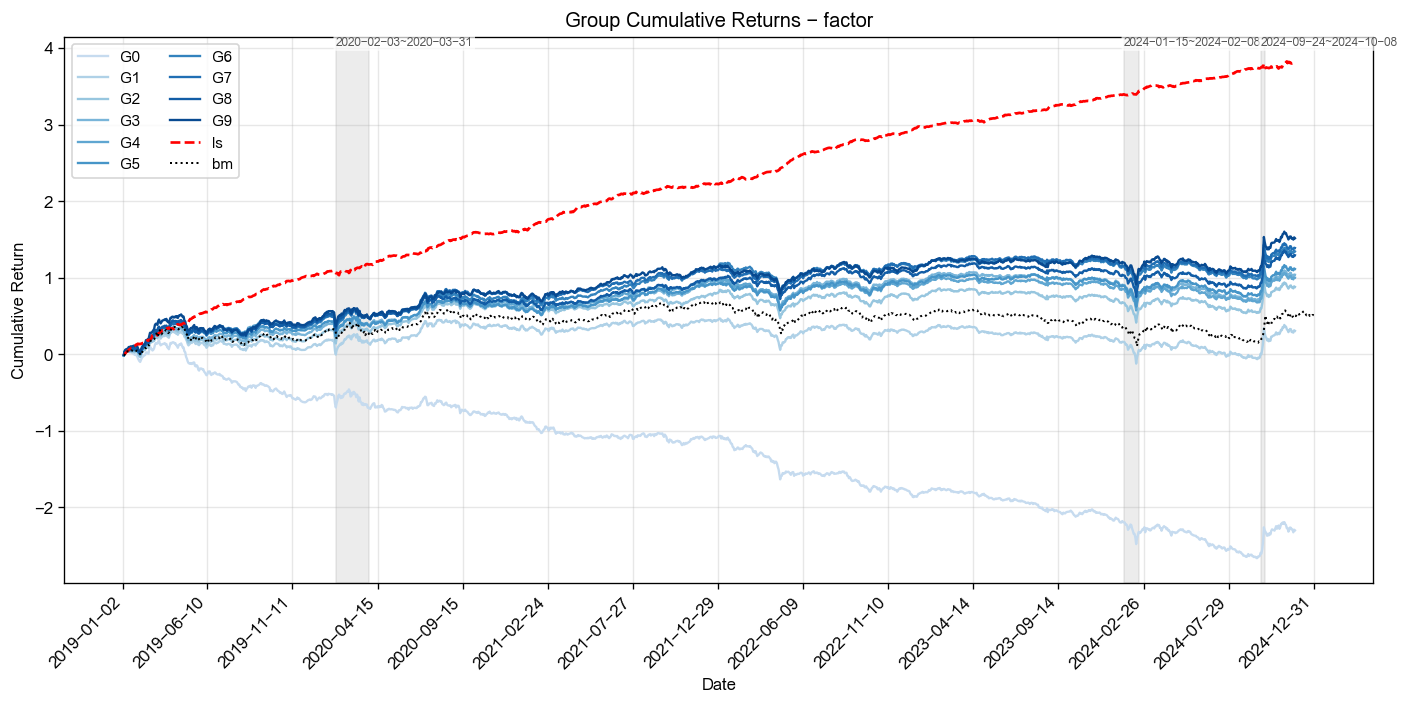
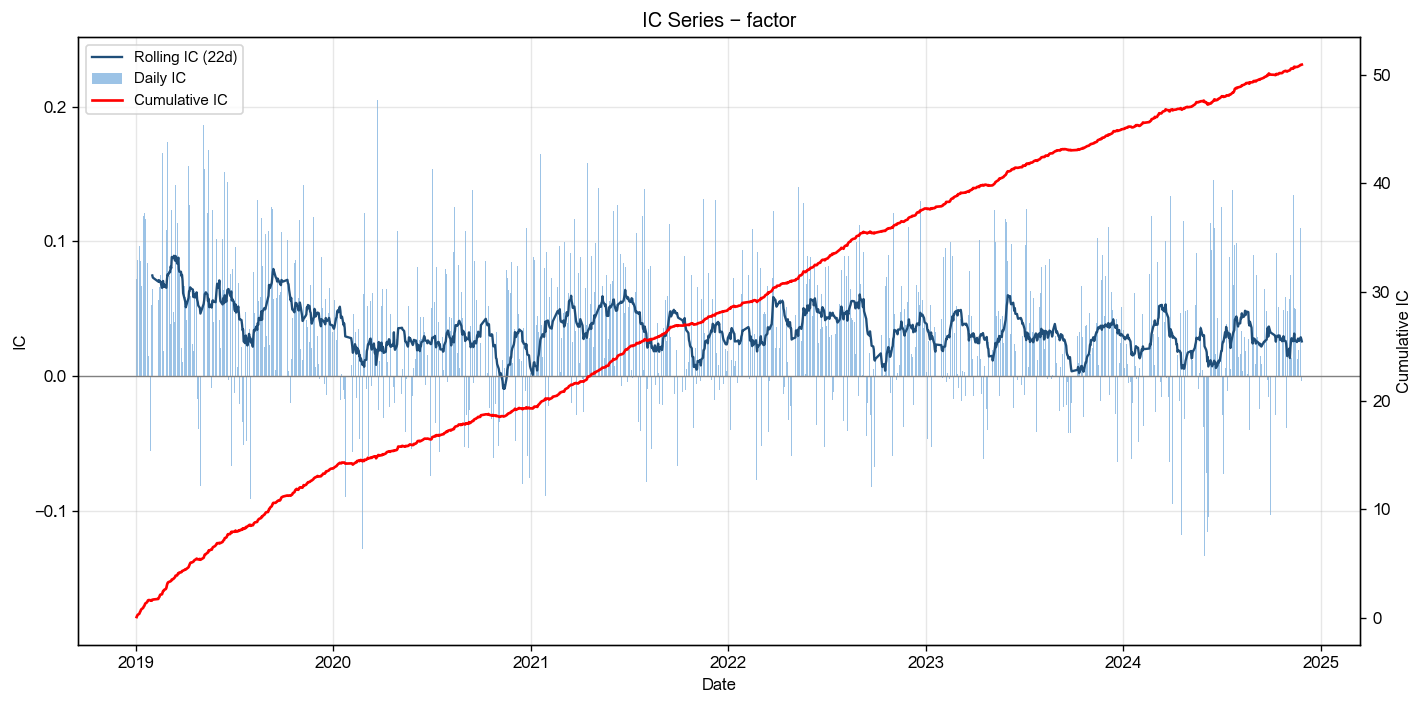
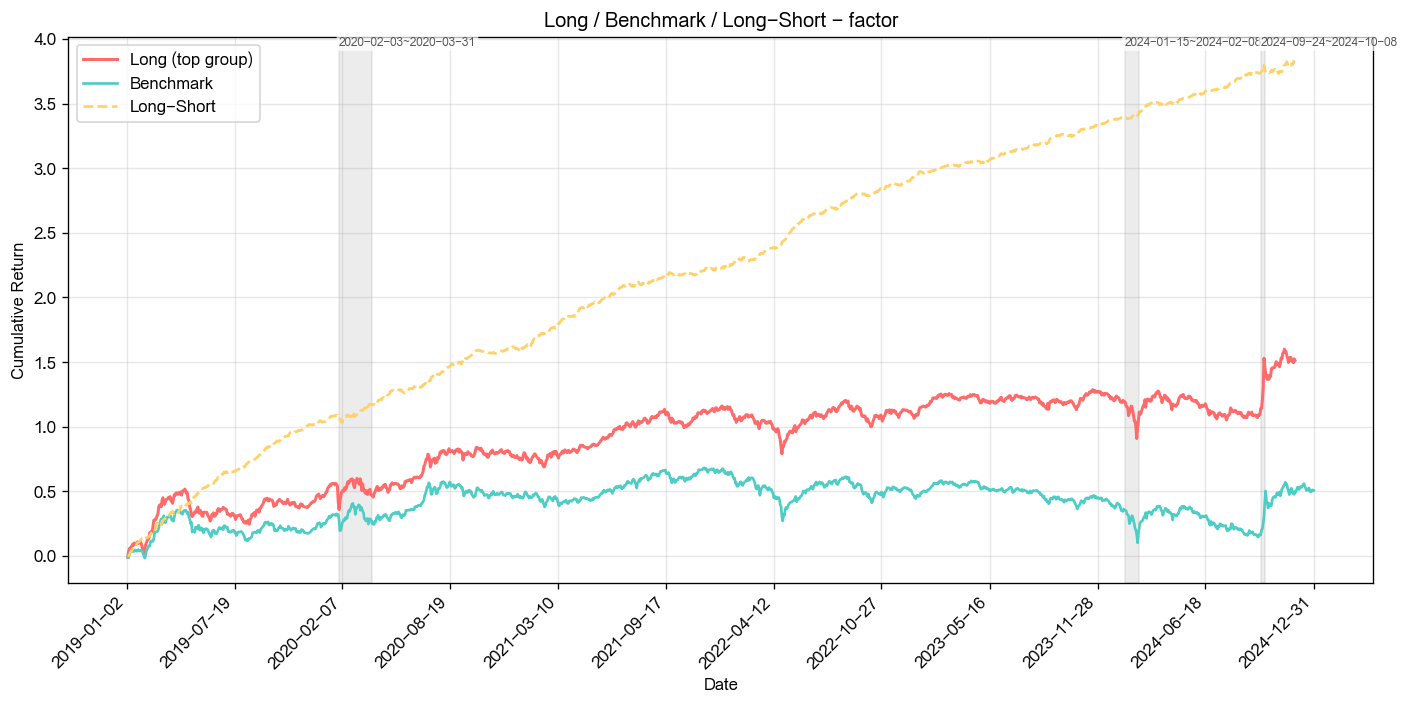
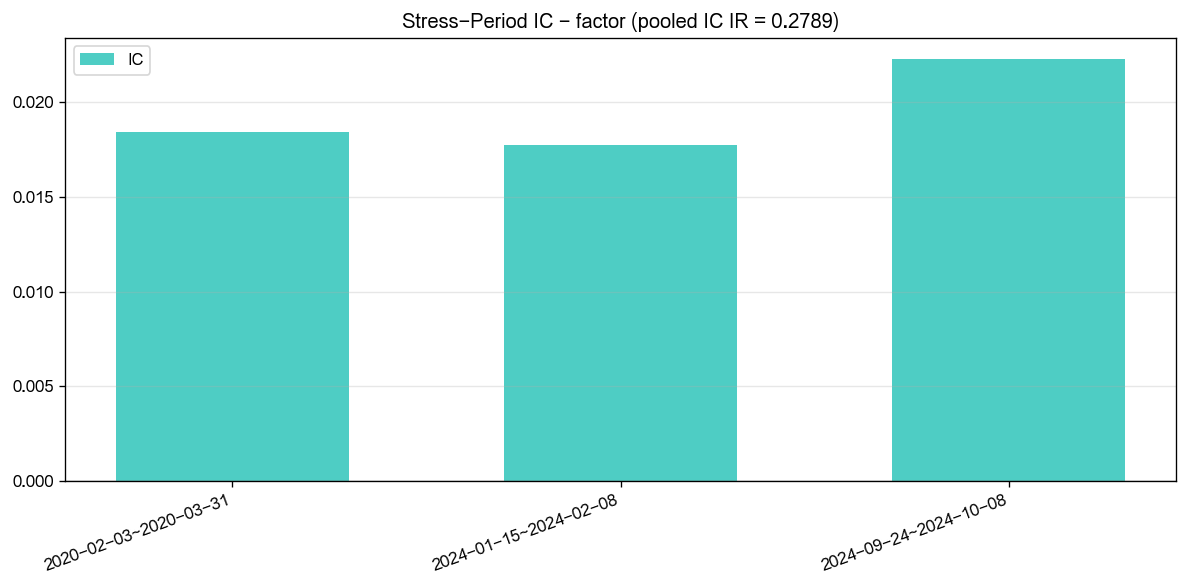
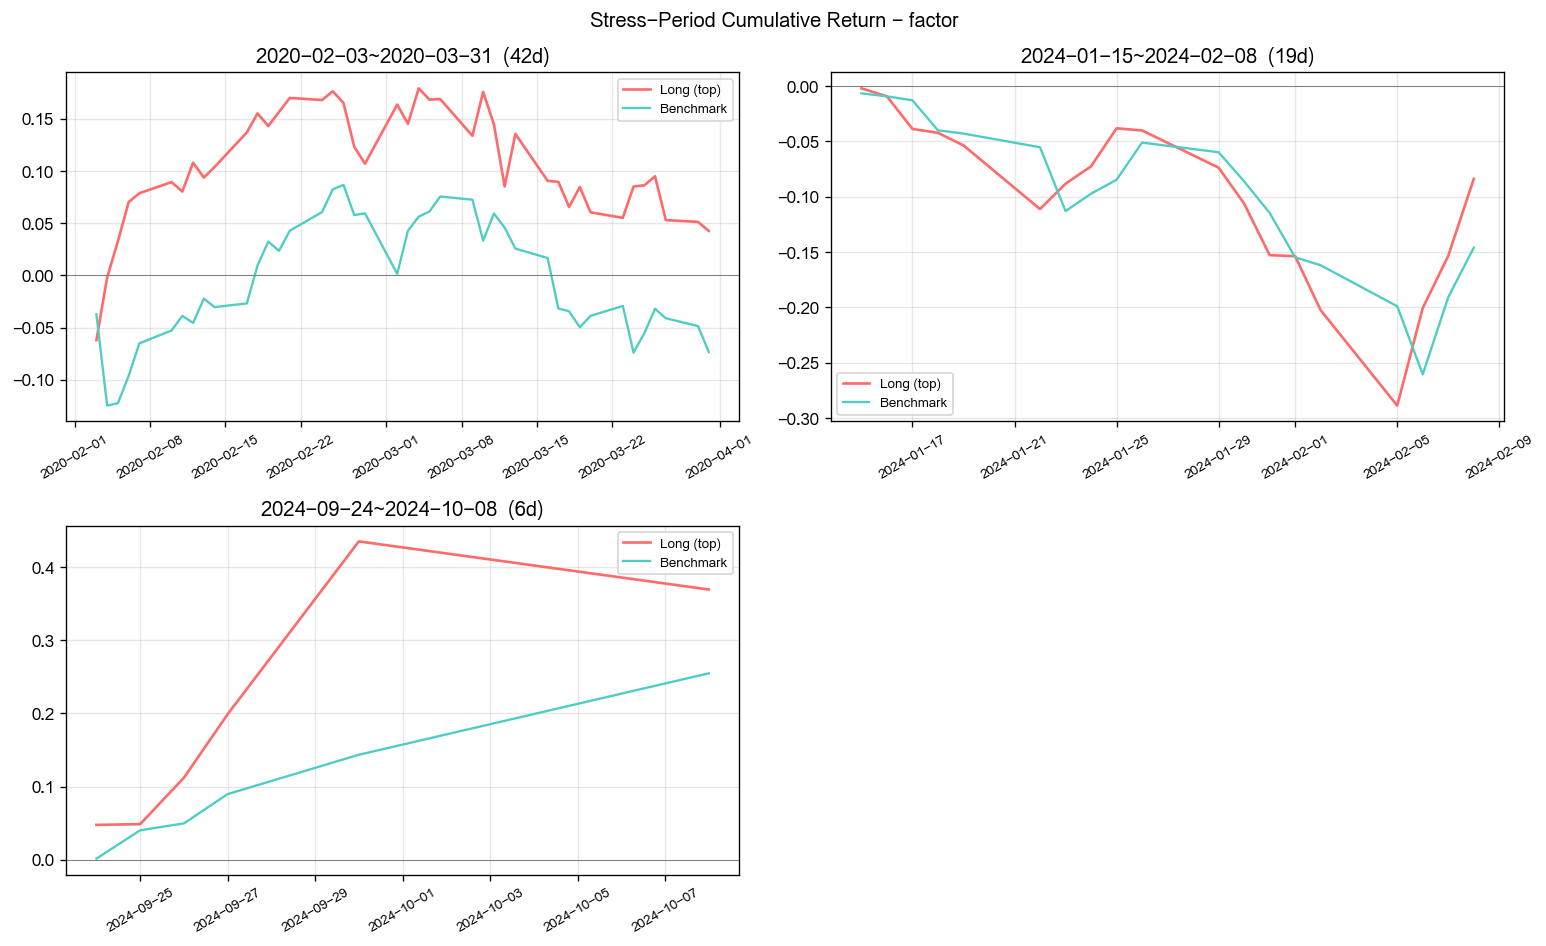

[2026-07-28 11:44:37] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-28 11:44:39] [warning  ] 返回的Outputs实例(size=218164437) 大于 64K, 将不会被缓存
[2026-07-28 11:44:39] [info     ] bigalpha_eval.v4 运行完成 [42.998s].


In [6]:
# 本地冒烟测试：模拟平台注入 datasources 与日期区间。
if __name__ == '__main__':
    from bigmodule import M
    datasources = {'bar5m': 'bigalpha_2026_stock_bar5m'}
    start_date, end_date = '2019-01-01 00:00:00', '2024-12-31 23:59:59'
    score_data = predict(datasources, start_date, end_date)
    print(score_data.head(), len(score_data), score_data.date.nunique())
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)


[2026-07-28 11:44:39][INFO] ============================================================
[2026-07-28 11:44:39][INFO] [main] start datasources=['bar5m'] range=[2024-01-01 00:00:00, 2024-12-31 23:59:59]
[2026-07-28 11:44:39][INFO] [mem] main start rss=21228.9MB
[2026-07-28 11:44:39][INFO] [main] table=bigalpha_2026_stock_bar5m
[2026-07-28 11:44:39][INFO] [main] fetching instrument pool
[2026-07-28 11:44:39][INFO] [main] pool rows=242000 unique_instruments=1206 elapsed=0.1s
[2026-07-28 11:44:39][INFO] [mem] after pool rss=21228.9MB
[2026-07-28 11:44:39][INFO] [main] year_chunks=1 total_days=365 use_chunked=False
[2026-07-28 11:44:39][INFO] [main] chunk 1/1 2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-28 11:44:39][INFO] [main] single-pass path
[2026-07-28 11:44:39][INFO] [dai] query start table=bigalpha_2026_stock_bar5m range=[2024-01-01 00:00:00, 2024-12-31 23:59:59] instruments=1206
[2026-07-28 11:44:39][INFO] [mem] before dai.query rss=21228.9MB
[2026-07-28 11:44:45][INFO] [dai] q

        date instrument     score
0 2024-01-02  000006.SZ  0.205691
1 2024-01-02  000012.SZ  0.194775
2 2024-01-02  000016.SZ  1.384080
3 2024-01-02  000019.SZ  0.601233
4 2024-01-02  000025.SZ  0.094995 241770 242
[2026-07-28 11:45:12] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-28 11:45:12] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-28 11:45:12] [info     ] 因子列名不为 factor, 自动重命名
[2026-07-28 11:45:12] [info     ] 未提供因子池，只进行单因子分析
[2026-07-28 11:45:12] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-28 11:45:12] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-28 11:45:12] [info     ] ========== 数据检查 ==========
[2026-07-28 11:45:12] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
[2026-07-28 11:45:12] [info     ] 通过：唯一性检查
[2026-07-28 11:45:12] [info     ] 通过：factor 有限值检查（禁止 inf/-inf）
[2026-07-28 11:45:12] [info     ] 通过：缺日检查（无整日全缺的交易日）
[2026-07-28 11:45:12] [info   

时段,IC
2024-01-15~2024-02-08,0.0146
2024-09-24~2024-10-08,0.0425

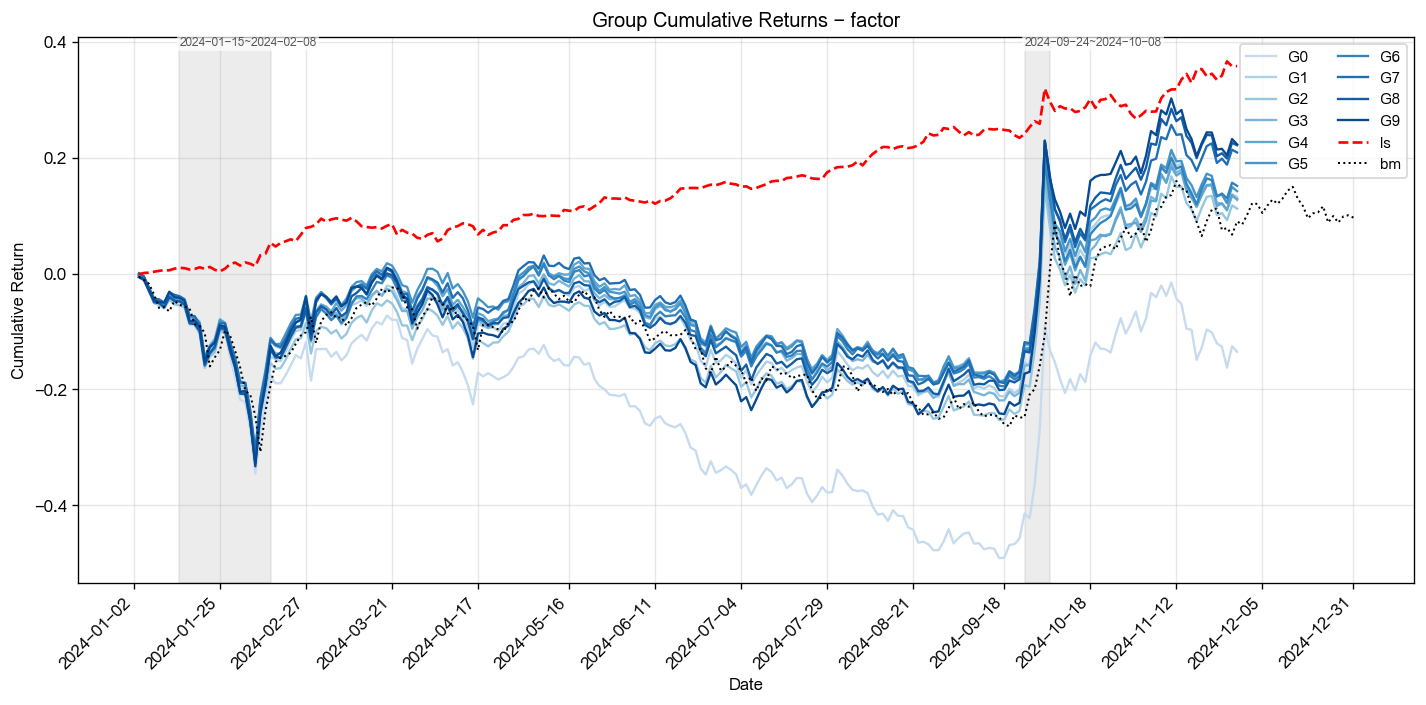
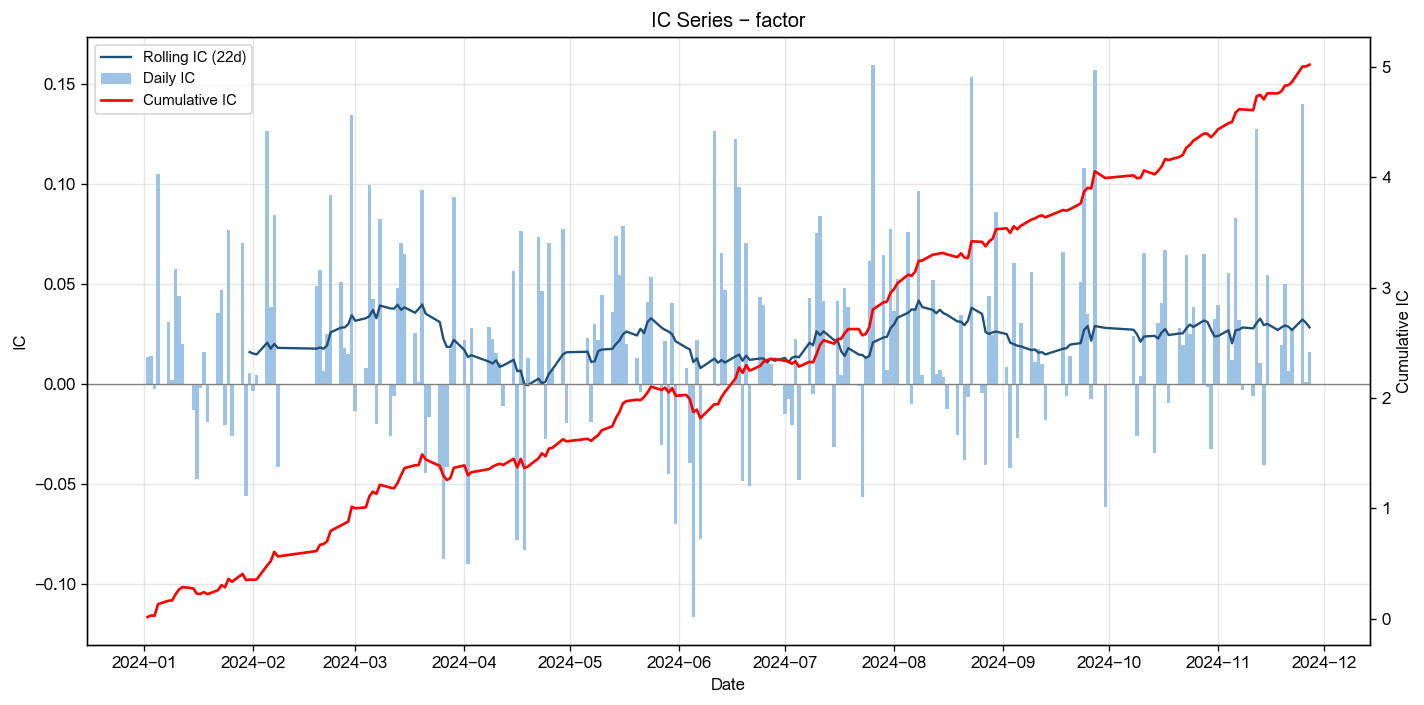
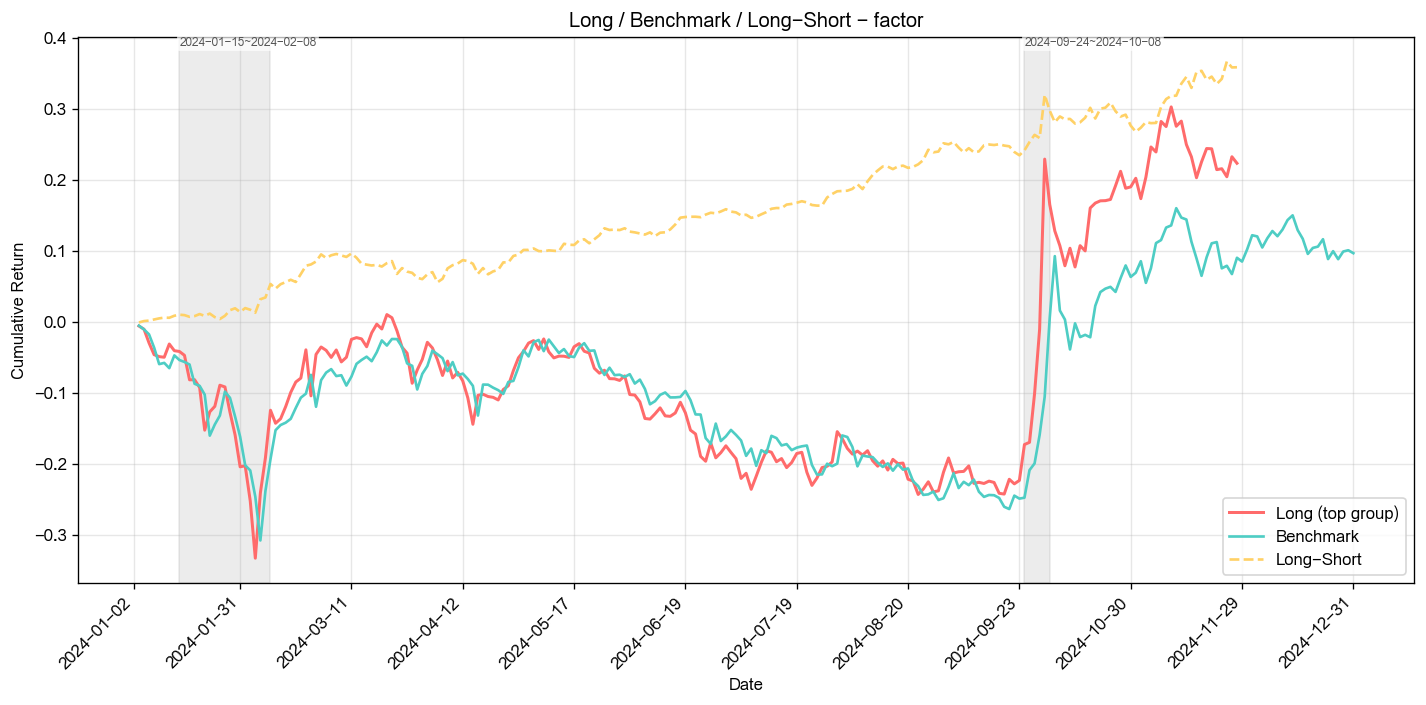
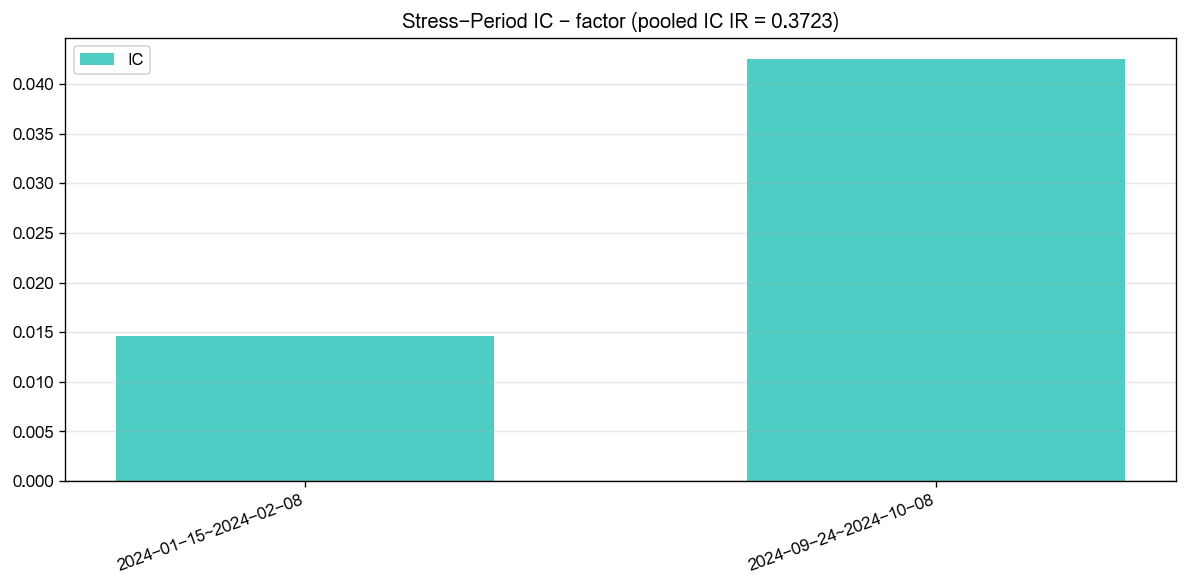
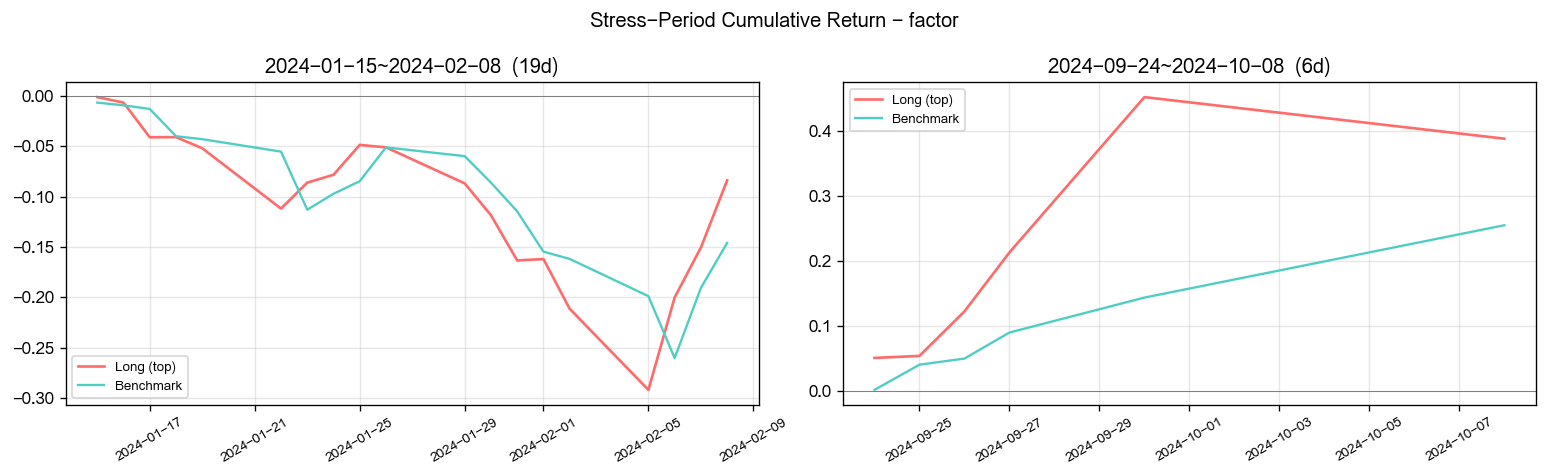

[2026-07-28 11:45:21] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-28 11:45:21] [warning  ] 返回的Outputs实例(size=35285435) 大于 64K, 将不会被缓存
[2026-07-28 11:45:21] [info     ] bigalpha_eval.v4 运行完成 [9.433s].


In [7]:
# 本地冒烟测试：模拟平台注入 datasources 与日期区间。
if __name__ == '__main__':
    from bigmodule import M
    datasources = {'bar5m': 'bigalpha_2026_stock_bar5m'}
    start_date, end_date = '2024-01-01 00:00:00', '2024-12-31 23:59:59'
    score_data = predict(datasources, start_date, end_date)
    print(score_data.head(), len(score_data), score_data.date.nunique())
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
